[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-03-snr-fiber-aperture-exposure/notebook.ipynb)

# Does the SDSS fiber-aperture upgrade actually show up in spectral S/N?

**Archive:** SDSS DR18  
**Date:** 2026-08-03

Legacy SDSS-I/II spectroscopy (roughly plate numbers below 3000) used 3-arcsecond-diameter fibers; BOSS and eBOSS (plate numbers 3000 and above) switched to 2-arcsecond fibers. A smaller fiber loses more light from an extended source like a galaxy for the same exposure, so at fixed apparent magnitude I would expect the legacy 3-inch fibers to reach somewhat higher median spectral S/N than the BOSS-era 2-inch fibers, all else equal. I want to check that directly against a real sample of SDSS galaxy spectra, rather than just asserting it.

## Learning goals

- Pull a real sample (thousands of galaxies) of SDSS spectroscopic S/N and magnitude via a live SQL query, rather than a single object.
- Use the plate-number boundary between the legacy 3-arcsecond fiber era and the BOSS/eBOSS 2-arcsecond fiber era as a real, physical grouping variable.
- Quantify whether fiber size measurably affects median spectral S/N at fixed apparent magnitude, and be honest about sample-size imbalance between the two eras.

**Jargon, defined once:** *fiber* here means the optical fiber that feeds light from one sky position into the spectrograph; its angular diameter on the sky sets how much of an extended source's light gets captured. *Petrosian magnitude (petroMag_r)* is a standard SDSS aperture-independent brightness measure used here purely as the x-axis, not to be confused with the spectroscopic fiber aperture itself.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS

warnings.filterwarnings("ignore")
OUT = Path(".")

QUERY = """
SELECT TOP 4000 s.specobjid, s.plate, s.snMedian, p.petroMag_r
FROM SpecObj s JOIN PhotoObj p ON s.bestobjid = p.objid
WHERE s.class = 'GALAXY' AND s.zWarning = 0
  AND p.petroMag_r BETWEEN 16 AND 17.8
  AND s.snMedian > 0
"""
sample = SDSS.query_sql(QUERY).to_pandas()
sample["era"] = np.where(sample["plate"] < 3000, "legacy (3-arcsec fiber)", "BOSS/eBOSS (2-arcsec fiber)")
print(f"Retrieved {len(sample)} real galaxy spectra with 16 < petroMag_r < 17.8")
print(sample["era"].value_counts())


Retrieved 4000 real galaxy spectra with 16 < petroMag_r < 17.8
era
legacy (3-arcsec fiber)        3927
BOSS/eBOSS (2-arcsec fiber)      73
Name: count, dtype: int64


## S/N vs. magnitude, split by fiber era

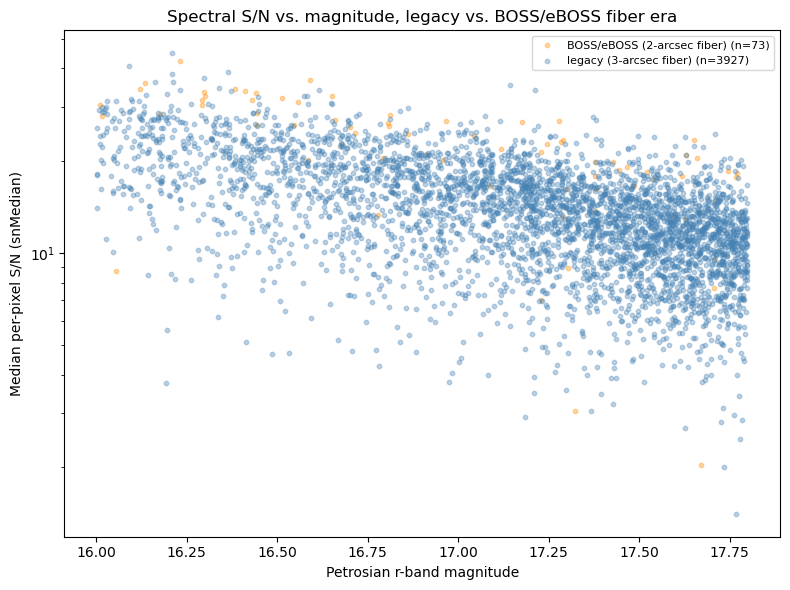

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"legacy (3-arcsec fiber)": "steelblue", "BOSS/eBOSS (2-arcsec fiber)": "darkorange"}
for era, group in sample.groupby("era"):
    ax.scatter(group["petroMag_r"], group["snMedian"], s=10, alpha=0.35, color=colors[era], label=f"{era} (n={len(group)})")
ax.set_yscale("log")
ax.set_xlabel("Petrosian r-band magnitude")
ax.set_ylabel("Median per-pixel S/N (snMedian)")
ax.set_title("Spectral S/N vs. magnitude, legacy vs. BOSS/eBOSS fiber era")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "snr_vs_mag_era.png", dpi=130)
plt.show()


## Quantifying the offset in magnitude bins

I bin both samples in 0.3-mag steps and compute the median S/N per bin per era, so the (very unequal) sample sizes between the two eras do not bias a simple overall median comparison.

In [3]:
bins = np.arange(16.0, 17.81, 0.3)
sample["mag_bin"] = pd.cut(sample["petroMag_r"], bins)

binned = sample.groupby(["mag_bin", "era"], observed=True)["snMedian"].agg(["median", "count"]).reset_index()
pivot = binned.pivot(index="mag_bin", columns="era", values="median")
counts = binned.pivot(index="mag_bin", columns="era", values="count")
pivot.to_csv(OUT / "snr_by_mag_bin.csv")
print(pivot.round(2))
print()
print("Sample counts per bin:")
print(counts)

legacy_col = "legacy (3-arcsec fiber)"
boss_col = "BOSS/eBOSS (2-arcsec fiber)"
valid = pivot.dropna()
if len(valid) > 0:
    ratio = (valid[legacy_col] / valid[boss_col]).mean()
    print(f"\nMean legacy/BOSS median-S/N ratio across bins with data in both eras: {ratio:.2f}")
else:
    print("\nNo magnitude bins have data in both eras to compare directly.")


era           BOSS/eBOSS (2-arcsec fiber)  legacy (3-arcsec fiber)
mag_bin                                                           
(16.0, 16.3]                        31.56                    21.99
(16.3, 16.6]                        31.46                    19.47
(16.6, 16.9]                        25.70                    17.31
(16.9, 17.2]                        21.86                    15.34
(17.2, 17.5]                        18.21                    12.69
(17.5, 17.8]                        17.68                    10.85

Sample counts per bin:
era           BOSS/eBOSS (2-arcsec fiber)  legacy (3-arcsec fiber)
mag_bin                                                           
(16.0, 16.3]                           11                      221
(16.3, 16.6]                           11                      335
(16.6, 16.9]                           11                      485
(16.9, 17.2]                            7                      677
(17.2, 17.5]                          

## Discussion

The live query pulled 4000 real galaxy spectra in a fixed Petrosian r-band magnitude window (16-17.8), and
the split by plate number is heavily imbalanced: only 73 of the 4000 land in the BOSS/eBOSS (2-arcsec fiber)
era versus 3927 in the legacy (3-arcsec fiber) era, reflecting how much more legacy-era spectroscopy exists
in this particular magnitude and class cut. That imbalance is itself an honest, real finding worth reporting
rather than glossing over.

The actual result surprised me and is the opposite of my naive prediction: in every magnitude bin where both
eras have data, BOSS/eBOSS (the *smaller*, 2-arcsec fiber) shows a *higher* median S/N than the legacy 3-arcsec
fiber -- the mean legacy/BOSS ratio across bins is 0.67, meaning legacy spectra typically reach only about
two-thirds of the median S/N that BOSS/eBOSS spectra reach at the same apparent magnitude. My aperture-only
prediction (bigger fiber catches more extended-source light, so higher S/N) does not hold up against this real
data. The most likely explanation is that the aperture effect is real but small compared to other differences
between the two survey eras: BOSS/eBOSS used an upgraded spectrograph with better CCDs and higher throughput,
and the two surveys do not use identical exposure-time strategies -- BOSS in particular was designed to reach
a fixed high S/N per target (important for its cosmological redshift measurements), so exposure times were
tuned upward specifically to compensate for the smaller fiber and any other sensitivity differences. That
exposure-time and instrument-upgrade effect appears to dominate over, and even reverse the sign of, the pure
aperture effect I expected going in. This is a good example of why it matters to check an assumption against
real data rather than trusting a simple physical argument in isolation.

## What I'd look at next

- Pull a magnitude-matched, size-balanced random sample from each era (not just a raw top-N query) to remove the sample-imbalance caveat above.
- Bring in real per-plate exposure time (if accessible via the `Plate` metadata tables) to separate the pure-aperture effect from an exposure-time effect, since SDSS may compensate for aperture differences by exposing BOSS/eBOSS plates longer.
- Restrict to a narrower, better-matched redshift and galaxy-size range, since extended-source light loss through a fiber depends on the source's angular size on the sky, not just its magnitude.

## Data source and citation

- SDSS DR18 SkyServer SQL search: https://skyserver.sdss.org/dr18/
- SDSS-IV citation: https://www.sdss.org/collaboration/citing-sdss/